In [1]:
import gamry_parser
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import splrep, splev
import math
from scipy.signal import savgol_filter

In [2]:
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data")

file_list = list(main_dir.rglob('*_1H.DTA'))


In [3]:
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    eis_data = {
        'name':str(filename).split("\\")[-1],
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }

    if float(((str(filename).split("\\")[-1]).split('_')[-1]).replace("H.DTA","")) < 24:
        k = 1
        K = 7
    else:
        k = 0.15
        K = 5
        
    w = np.ones(len(data['Freq'].values))
    w[data['Freq'].values < k] = 0.5
    w[data['Freq'].values > k] = 10
    
    sigma_auto = np.std(np.diff(data['Zphz'].values[data['Freq'].values < 0.1]))
    s = (sigma_auto/10*len(data['Freq'].values))
                                              
    sigma_auto1 = np.std(np.diff(data['Zreal'].values[data['Freq'].values < 0.1]))/np.mean(data['Zmod'].values[data['Freq'].values < 0.1])
    s1 = sigma_auto1*len(data['Freq'].values)
    
    sigma_auto2 = np.std(np.diff(data['Zimag'].values[data['Freq'].values < 0.1]))/np.mean(data['Zmod'].values[data['Freq'].values < 0.1])
    s2 = (sigma_auto2*len(data['Freq'].values))
    
    spl_Zreal = splrep(np.log10(np.flip(data['Freq'].values)), np.flip(data['Zreal'].values),np.flip(w), s = (sigma_auto1*K*np.mean(data['Zmod'].values))**2)
    spl_Zimag = splrep(np.log10(np.flip(data['Freq'].values)), np.flip(data['Zimag'].values),np.flip(w), s = (sigma_auto2*K*np.mean(data['Zmod'].values))**2)
    spl_Zmod = splrep(np.log10(np.flip(data['Freq'].values)), np.log10(np.flip(data['Zmod'].values)),np.flip(w),s = s/1e4)
    spl_Zphz = splrep(np.flip(data['Freq'].values), np.flip(data['Zphz'].values),np.flip(w), s = s)

    eis_data_filtered = {
        'name':str(filename).split("\\")[-1],
        'Zreal':splev(np.log10(np.flip(data['Freq'].values)),spl_Zreal),
        'Zimag':-splev(np.log10(np.flip(data['Freq'].values)),spl_Zimag),
        'Zmod':splev(np.log10(np.flip(data['Freq'].values)),spl_Zmod),
        'Zphz':splev(np.flip(data['Freq'].values),spl_Zphz),
        'Freq':np.flip(data['Freq'].values)
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_data_filtered":eis_data_filtered})
    print(eis_data['name'])



Cauvel_2_8HQ_1H.DTA
Cauvel_3_BTA_1H.DTA
Cauvel_1_Lcystine_1H.DTA
Cauvel_1_MBT_1H.DTA
Cauvel_3_Mo_1H.DTA
Cauvel_4_NaCl_1H.DTA
Cauvel_2_NaVO3_1H.DTA
Cauvel_4_NaVO3_1H.DTA


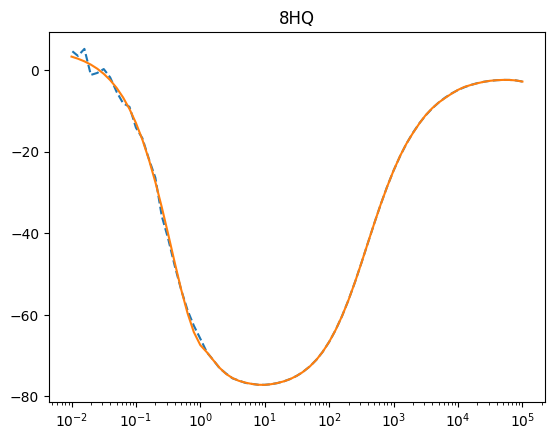

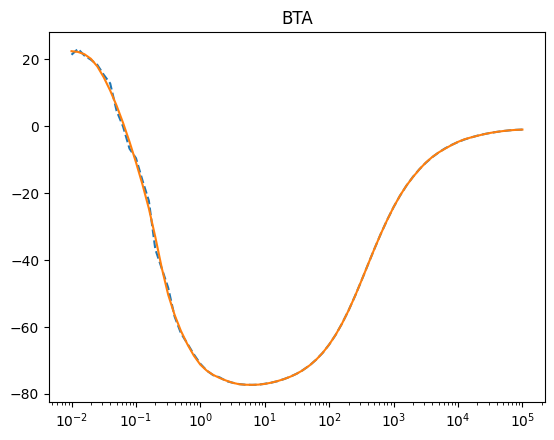

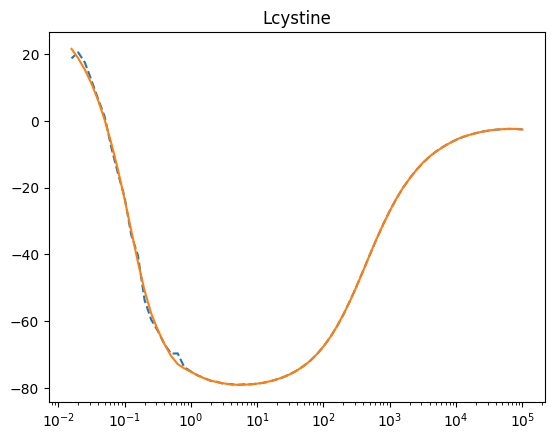

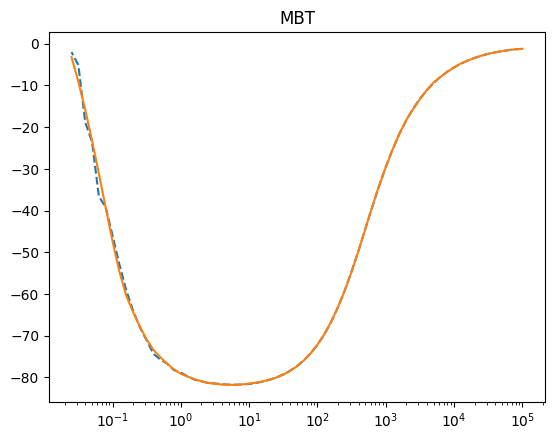

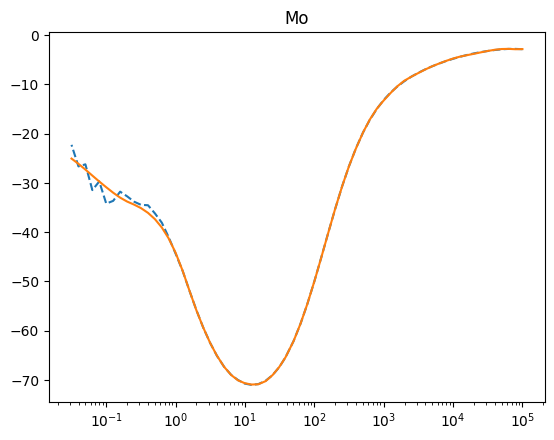

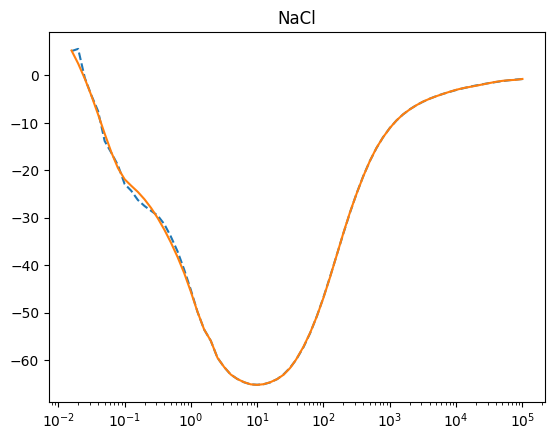

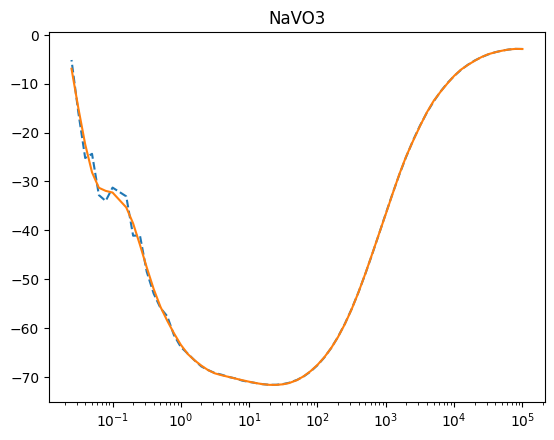

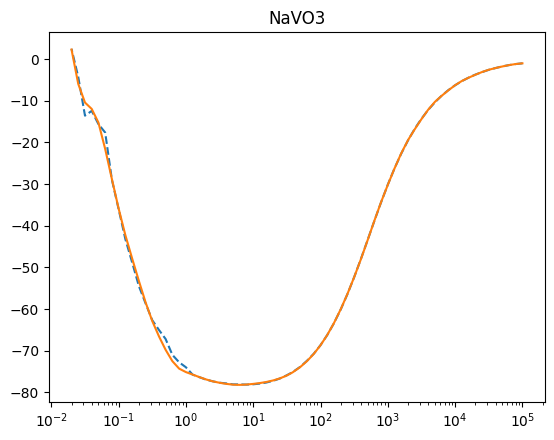

In [4]:
for i, dataset in enumerate(all_datasets):
    plt.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'], '--')
    plt.semilogx(dataset['eis_data_filtered']['Freq'], dataset['eis_data_filtered']['Zphz'])
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()

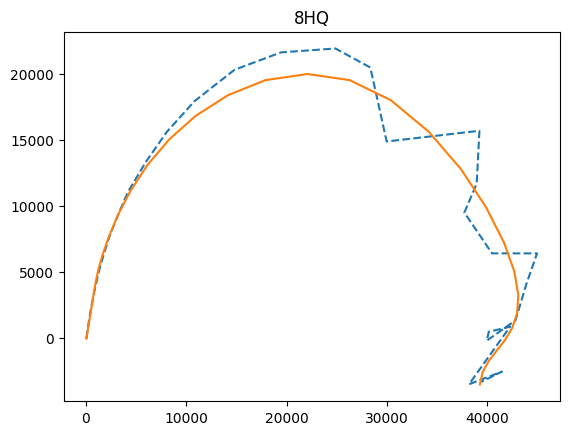

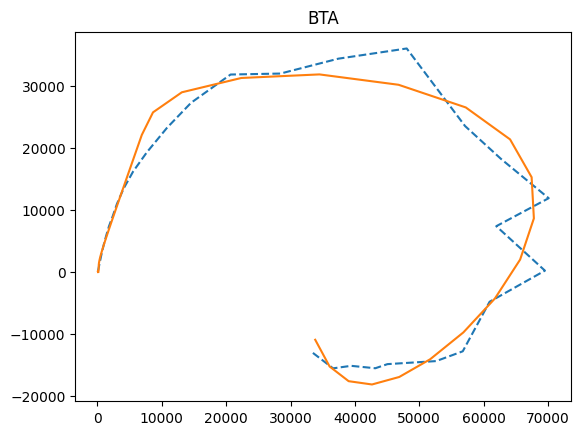

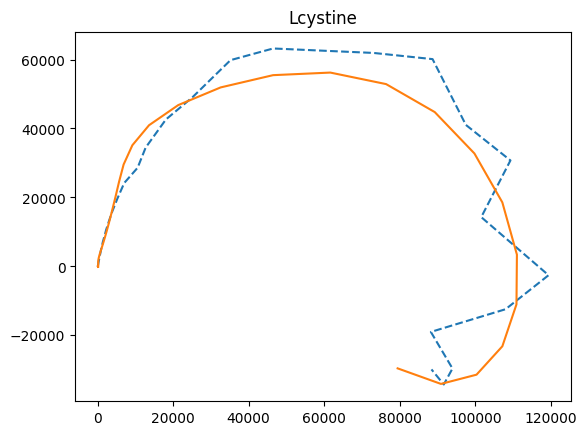

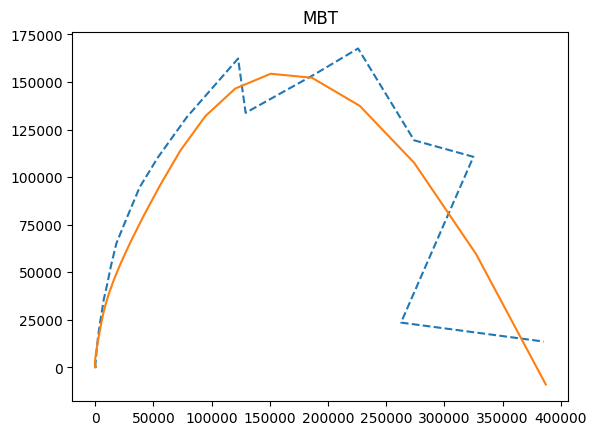

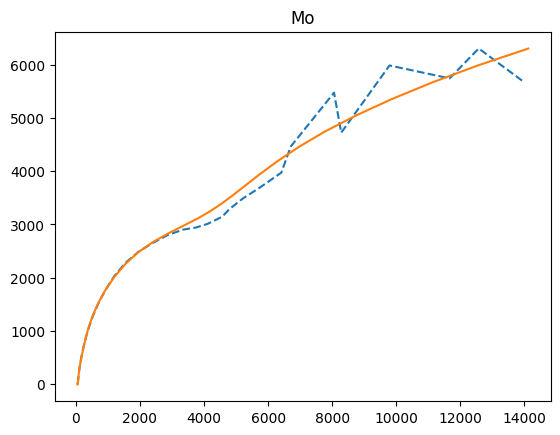

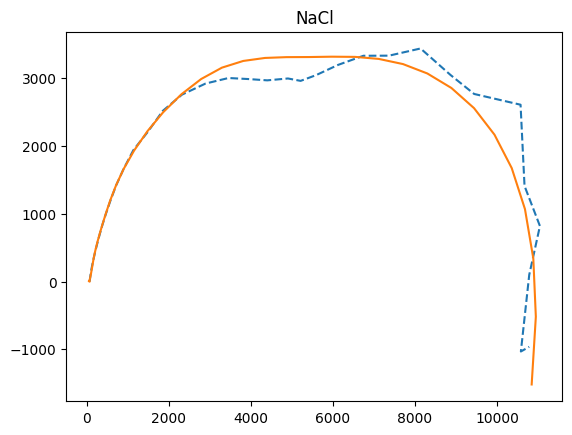

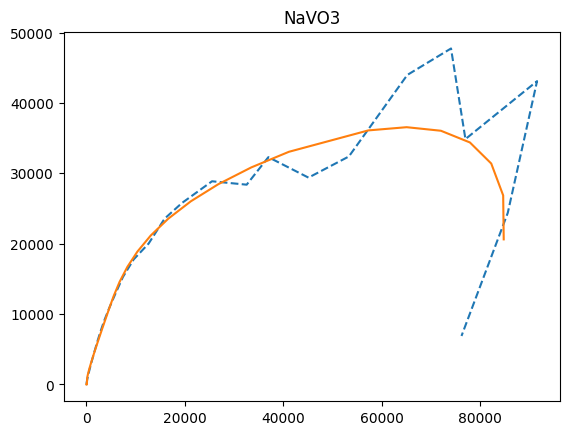

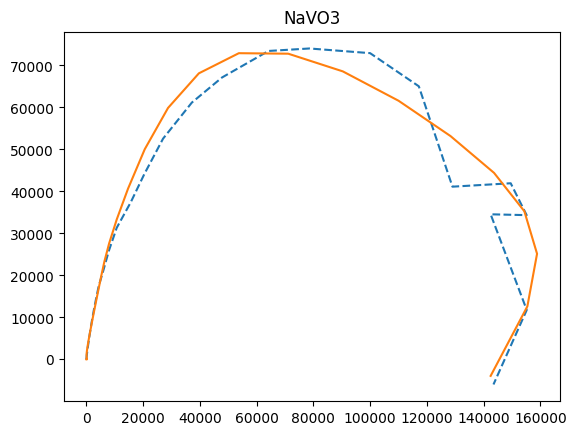

In [5]:
for i, dataset in enumerate(all_datasets):
    plt.plot(dataset['eis_data']['Zreal'],dataset['eis_data']['Zimag'],'--')
    plt.plot(dataset['eis_data_filtered']['Zreal'], dataset['eis_data_filtered']['Zimag'],)
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()

In [6]:
colors = ['black', 'red', 'blue', 'green', 'magenta', 'olive', 'cyan', 'hotpink']
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3': r'NaVO$_3$',      
    'NaCl': 'NaCl',            
    '8HQ': '8HQ',              
    'BTA': 'BTA',
    'Lcystine': 'L-Cystine',   
    'MBT': 'MBT',
    'Mo': 'Na$_2$MoO$_4$'
}

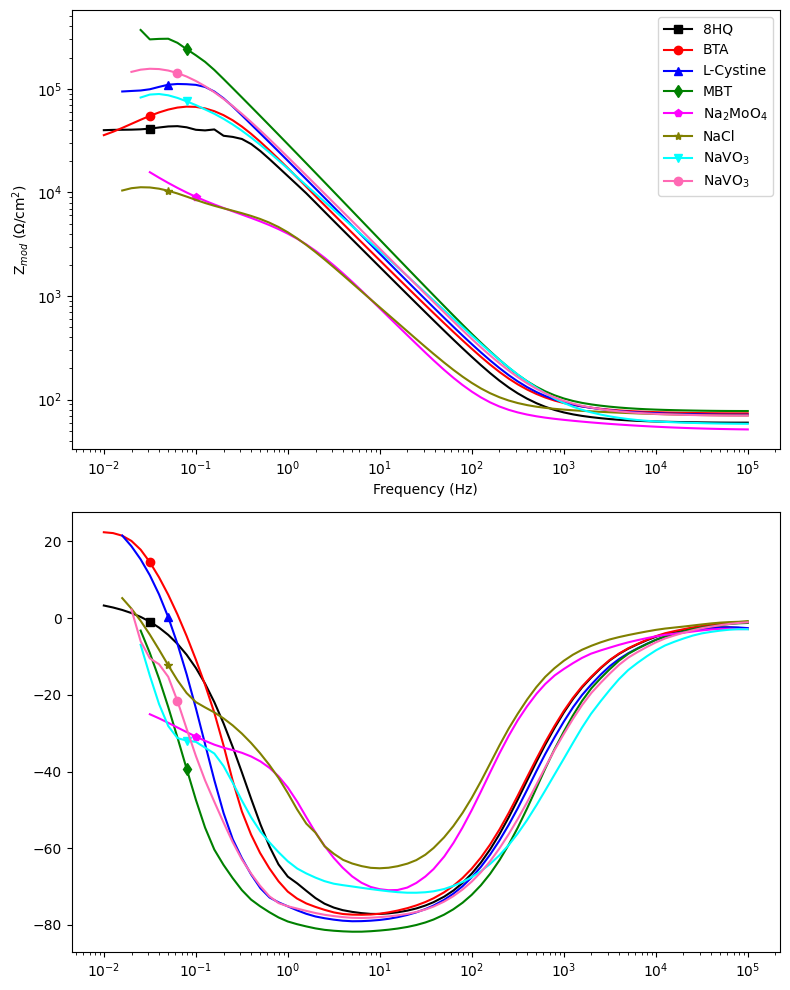

In [7]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize = (8,10))

for i, dataset in enumerate(all_datasets):
    #ax1.loglog(dataset['eis_data']['Freq'],dataset['eis_data']['Zmod'],label = dataset['eis_data_filtered']['name'])
    raw_name = dataset['eis_data_filtered']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax1.loglog(
        dataset['eis_data_filtered']['Freq'],
        10**dataset['eis_data_filtered']['Zmod'],
        label=label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         
        markersize=6,          
        markevery=(5,70)
    )
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
    ax1.legend()

for i, dataset in enumerate(all_datasets):
    #ax2.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'],label = dataset['eis_data_filtered']['name'])
    ax2.semilogx(
        dataset['eis_data_filtered']['Freq'],
        dataset['eis_data_filtered']['Zphz'],
        label = dataset['eis_data_filtered']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,70)
    )

plt.tight_layout()
plt.show()

[np.float64(10945.685051162045), np.float64(14120.590491682917), np.float64(43099.86148168307), np.float64(67816.16605597944), np.float64(84790.47691268394), np.float64(110996.65014311898), np.float64(158786.3997208046), np.float64(387077.3032027306)]


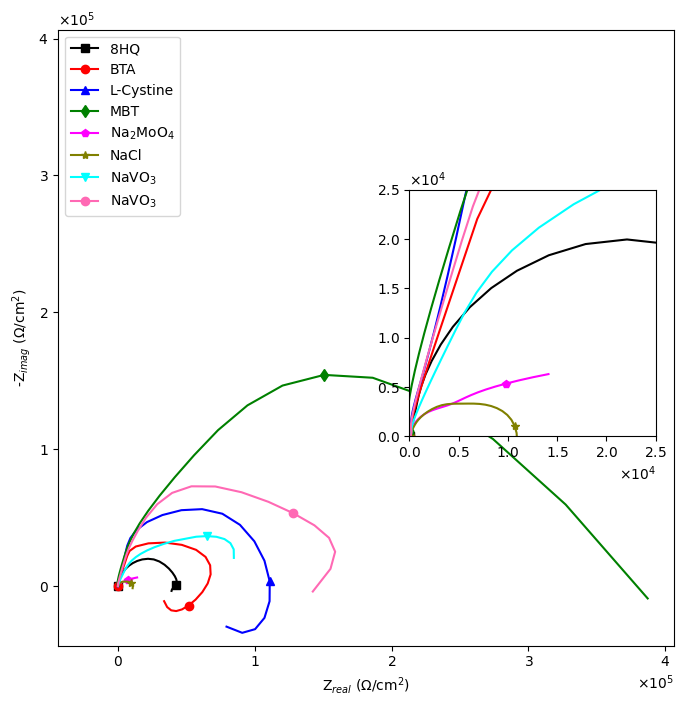

In [8]:
fig2, ax3 = plt.subplots(figsize=(8, 8))
axins = ax3.inset_axes([0.57, 0.34, 0.4, 0.4])
Max_Zreals = []
Max_Zimags = []

main_step = 100e3
inset_step = 5e3

for i, dataset in enumerate(all_datasets):
    raw_name = dataset['eis_data_filtered']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax3.plot(
        dataset['eis_data_filtered']['Zreal'],
        dataset['eis_data_filtered']['Zimag'],
        label = label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    ax3.legend(loc = 'upper left')
    ax3.xaxis.set_major_locator(MultipleLocator(main_step))
    ax3.yaxis.set_major_locator(MultipleLocator(main_step))
    ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    axins.plot(
        dataset['eis_data_filtered']['Zreal'],
        dataset['eis_data_filtered']['Zimag'],
        label = dataset['eis_data_filtered']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(3,65)
    )
    axins.xaxis.set_major_locator(MultipleLocator(inset_step))
    axins.yaxis.set_major_locator(MultipleLocator(inset_step))
    axins.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    max_Zreals = dataset['eis_data_filtered']['Zreal'].max()
    max_Zimags = dataset['eis_data_filtered']['Zimag'].max()
    Max_Zreals.append(max_Zreals)
    Max_Zimags.append(max_Zimags)


ax3.set_aspect('equal')
ax3.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)')
ax3.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)')


Max_Zreals.sort()
print(Max_Zreals)

axins.set_xlim(0, 25000)
axins.set_ylim(0, 25000)
#print(overall_min_inset,overall_max_inset)

x_min, x_max = ax3.get_xlim()
y_min, y_max = ax3.get_ylim()
overall_min = min(x_min, y_min)
overall_max = max(x_max, y_max)
ax3.set_xlim(overall_min, overall_max)
ax3.set_ylim(overall_min, overall_max)

plt.show()

